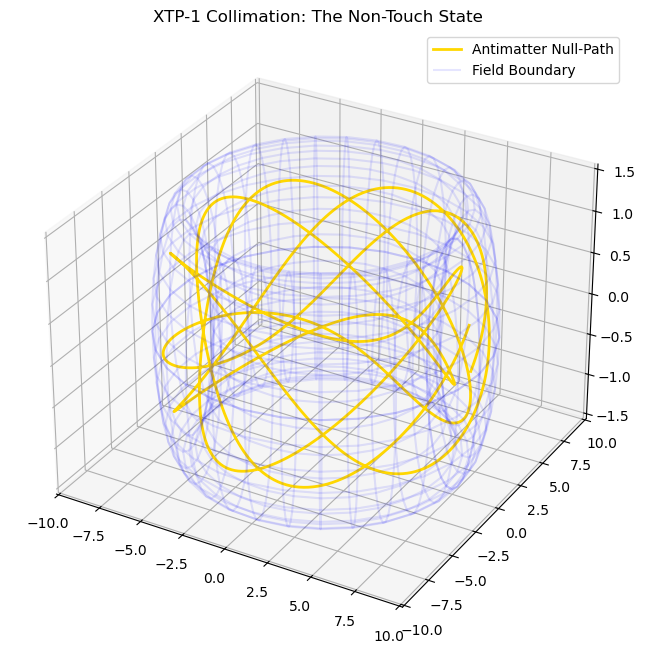

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Constants of the Manifold
phi = (1 + 5**0.5) / 2  # The Proportional Torsion
pi = np.pi               # The Radial Torsion
e = np.e                # The Growth Torsion

# Simulation Parameters
steps = 1000
t = np.linspace(0, 10 * pi, steps)

# 1. The Toroidal Path (Longitudinal Flow)
# We use 'e' to define the expansion/stability of the ring
R = e**2 
r = 1.0   # Minor radius

# 2. The Poloidal-Toroidal Collimation
# We balance the fields such that the particle follows the phi-ratio path
# This creates the "Null-Track" where the particle is centripetally locked
x = (R + r * np.cos(t * phi)) * np.cos(t)
y = (R + r * np.cos(t * phi)) * np.sin(t)
z = r * np.sin(t * phi)

# 3. Plotting the Collimated Trace
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.plot(x, y, z, label='Antimatter Null-Path', color='gold', lw=2)

# Visualization of the "Field Boundary" (The 3D Grid)
# We show that the particle (gold line) never touches the 'wall'
u, v = np.mgrid[0:2*np.pi:30j, 0:2*np.pi:30j]
x_wall = (R + 1.5 * np.cos(u)) * np.cos(v)
y_wall = (R + 1.5 * np.cos(u)) * np.sin(v)
z_wall = 1.5 * np.sin(u)
ax.plot_wireframe(x_wall, y_wall, z_wall, color='blue', alpha=0.1, label='Field Boundary')

ax.set_title("XTP-1 Collimation: The Non-Touch State")
ax.legend()
plt.show()

In [18]:
from IPython.display import HTML

html_code = """
<div id="collimator-laminar-frame" style="width: 100%; height: 1800px; background-color: #FFF; border: 2px solid #CCC; overflow: hidden;"></div>
<script src="https://cdnjs.cloudflare.com/ajax/libs/three.js/r128/three.min.js"></script>
<script>
    (function() {
        const container = document.getElementById('collimator-laminar-frame');
        const scene = new THREE.Scene();
        scene.background = new THREE.Color(0xffffff); 
        
        const camera = new THREE.PerspectiveCamera(60, container.offsetWidth / 1800, 0.1, 2000);
        const renderer = new THREE.WebGLRenderer({ antialias: true });
        renderer.setSize(container.offsetWidth, 1800);
        container.appendChild(renderer.domElement);

        // Moscow Manifold Invariants
        const phi = (1 + Math.sqrt(5)) / 2;
        const R = 7.389; // e^2
        const r_beam = 0.9; 
        const r_field = 1.8; 

        // 1. Magnetic Field Flux Lines (The Cage)
        for (let i = 0; i < 36; i++) {
            let angle = (i / 36) * Math.PI * 2;
            let pGeo = new THREE.CircleGeometry(r_field, 128); 
            let pEdges = new THREE.EdgesGeometry(pGeo);
            let pLine = new THREE.LineSegments(pEdges, new THREE.LineBasicMaterial({ 
                color: 0x0044CC, 
                opacity: 0.3, 
                transparent: true 
            }));
            
            pLine.position.x = R * Math.cos(angle);
            pLine.position.z = R * Math.sin(angle);
            pLine.rotation.y = -angle;
            scene.add(pLine);
        }

        // 2. The Gold Torsional Braid (The Geodesic Path)
        const curvePoints = [];
        for (let t = 0; t < 15 * Math.PI; t += 0.03) {
            let x = (R + r_beam * Math.cos(t * phi)) * Math.cos(t);
            let z = (R + r_beam * Math.cos(t * phi)) * Math.sin(t);
            let y = r_beam * Math.sin(t * phi);
            curvePoints.push(new THREE.Vector3(x, y, z));
        }
        const curveGeo = new THREE.BufferGeometry().setFromPoints(curvePoints);
        const braid = new THREE.Line(curveGeo, new THREE.LineBasicMaterial({ 
            color: 0xB8860B, 
            opacity: 0.4, 
            transparent: true 
        }));
        scene.add(braid);

        // 3. The Laminar Sovereign Integers (6 Red Dots)
        const particleCount = 6;
        const particles = [];
        const dotGeo = new THREE.SphereGeometry(0.275, 64, 64);
        const dotMat = new THREE.MeshBasicMaterial({ color: 0xEE0000 });

        for (let i = 0; i < particleCount; i++) {
            const redDot = new THREE.Mesh(dotGeo, dotMat);
            scene.add(redDot);
            particles.push(redDot);
        }

        camera.position.set(25, 18, 25);
        camera.lookAt(0, 0, 0);

        let clock = 0;
        function animate() {
            requestAnimationFrame(animate);
            clock += 0.018; 

            // Update each particle with a torsional offset
            for (let i = 0; i < particles.length; i++) {
                // Offset: evenly spaced through the 12*PI main pulse
                let timeOffset = clock + (i * (12 * Math.PI / particleCount));
                
                particles[i].position.x = (R + r_beam * Math.cos(timeOffset * phi)) * Math.cos(timeOffset);
                particles[i].position.z = (R + r_beam * Math.cos(timeOffset * phi)) * Math.sin(timeOffset);
                particles[i].position.y = r_beam * Math.sin(timeOffset * phi);
            }

            scene.rotation.y += 0.001; 
            renderer.render(scene, camera);
        }
        animate();
    })();
</script>
"""

HTML(html_code)

In [19]:
from IPython.display import HTML

html_code = """
<div id="xtp1-synthesis-frame" style="width: 100%; height: 1800px; background-color: #FFF; border: 2px solid #CCC; overflow: hidden;"></div>
<script src="https://cdnjs.cloudflare.com/ajax/libs/three.js/r128/three.min.js"></script>
<script>
    (function() {
        const container = document.getElementById('xtp1-synthesis-frame');
        const scene = new THREE.Scene();
        scene.background = new THREE.Color(0xffffff); 
        
        const camera = new THREE.PerspectiveCamera(60, container.offsetWidth / 1800, 0.1, 2000);
        const renderer = new THREE.WebGLRenderer({ antialias: true });
        renderer.setSize(container.offsetWidth, 1800);
        container.appendChild(renderer.domElement);

        const phi = (1 + Math.sqrt(5)) / 2;
        const R = 7.389; // e^2
        const r_beam = 0.9; 
        const r_field = 1.8; 

        // 1. Lonsdaleite Lattice (Hexagonal Diamond Core)
        const latticeGroup = new THREE.Group();
        const atomGeo = new THREE.SphereGeometry(0.15, 16, 16);
        const atomMat = new THREE.MeshPhongMaterial({ color: 0x888888, shininess: 100 });
        const bondMat = new THREE.LineBasicMaterial({ color: 0xAAAAAA, opacity: 0.3, transparent: true });

        // Build a basic Hexagonal Unit Cell
        for (let i = -2; i <= 2; i++) {
            for (let j = -2; j <= 2; j++) {
                for (let k = -1; k <= 1; k++) {
                    let x = i * 1.5 + (j % 2) * 0.75;
                    let z = j * 1.3;
                    let y = k * 1.5;
                    
                    const atom = new THREE.Mesh(atomGeo, atomMat);
                    atom.position.set(x, y, z);
                    latticeGroup.add(atom);
                }
            }
        }
        scene.add(latticeGroup);
        
        // Lighting for the Lattice
        const light = new THREE.PointLight(0xffffff, 1, 100);
        light.position.set(10, 10, 10);
        scene.add(light);
        scene.add(new THREE.AmbientLight(0x404040));

        // 2. Magnetic Flux Rings
        for (let i = 0; i < 36; i++) {
            let angle = (i / 36) * Math.PI * 2;
            let pGeo = new THREE.CircleGeometry(r_field, 64);
            let pLine = new THREE.LineSegments(new THREE.EdgesGeometry(pGeo), 
                new THREE.LineBasicMaterial({ color: 0x0044CC, opacity: 0.2, transparent: true }));
            pLine.position.x = R * Math.cos(angle);
            pLine.position.z = R * Math.sin(angle);
            pLine.rotation.y = -angle;
            scene.add(pLine);
        }

        // 3. Gold Path (Torsional Braid)
        const curvePoints = [];
        for (let t = 0; t < 15 * Math.PI; t += 0.03) {
            curvePoints.push(new THREE.Vector3(
                (R + r_beam * Math.cos(t * phi)) * Math.cos(t),
                r_beam * Math.sin(t * phi),
                (R + r_beam * Math.cos(t * phi)) * Math.sin(t)
            ));
        }
        scene.add(new THREE.Line(new THREE.BufferGeometry().setFromPoints(curvePoints), 
            new THREE.LineBasicMaterial({ color: 0xB8860B, opacity: 0.3, transparent: true })));

        // 4. Six Red Sovereign Integers
        const particles = [];
        for (let i = 0; i < 6; i++) {
            const p = new THREE.Mesh(new THREE.SphereGeometry(0.2, 32, 32), new THREE.MeshBasicMaterial({ color: 0xEE0000 }));
            scene.add(p);
            particles.push(p);
        }

        camera.position.set(25, 20, 25);
        camera.lookAt(0, 0, 0);

        let clock = 0;
        function animate() {
            requestAnimationFrame(animate);
            clock += 0.015; 
            
            particles.forEach((p, i) => {
                let t = clock + (i * (12 * Math.PI / 6));
                p.position.set(
                    (R + r_beam * Math.cos(t * phi)) * Math.cos(t),
                    r_beam * Math.sin(t * phi),
                    (R + r_beam * Math.cos(t * phi)) * Math.sin(t)
                );
            });

            latticeGroup.rotation.y += 0.005; // Independent rotation of the crystal core
            scene.rotation.y += 0.001; 
            renderer.render(scene, camera);
        }
        animate();
    })();
</script>
"""

HTML(html_code)